In [51]:
%matplotlib qt

In [3]:
# DripSense: Machine Learning Based Leak Detection System

# DripSense is a machine learning system designed to detect anomalies in fluid pipeline systems such as water, oil, or gas pipelines.

# The system analyzes sensor data such as:
# - Flow rate
# - Pressure
# - Temperature
# - Vibration

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

In [5]:
np.random.seed(42)
samples = 2000
flow_rate = np.random.normal(50, 5, samples)
pressure = np.random.normal(100, 10, samples)
temperature = np.random.normal(30, 3, samples)
vibration = np.random.normal(5, 1, samples)
data = pd.DataFrame({
    "flow_rate": flow_rate,
    "pressure": pressure,
    "temperature": temperature,
    "vibration": vibration
})
data.head()

,flow_rate,pressure,temperature,vibration
0,52.483571,93.248217,27.409519,3.885919
1,49.308678,98.554813,29.906390,4.369069
2,53.238443,92.075801,30.054051,4.057940
3,57.615149,96.920385,31.417891,4.452004
4,48.829233,81.063853,25.899425,4.785850


In [6]:
leak_indices = np.random.choice(samples, 100)
data["leak"] = 0
data.loc[leak_indices, "flow_rate"] -= 20
data.loc[leak_indices, "pressure"] -= 30
data.loc[leak_indices, "vibration"] += 3
data.loc[leak_indices, "leak"] = 1

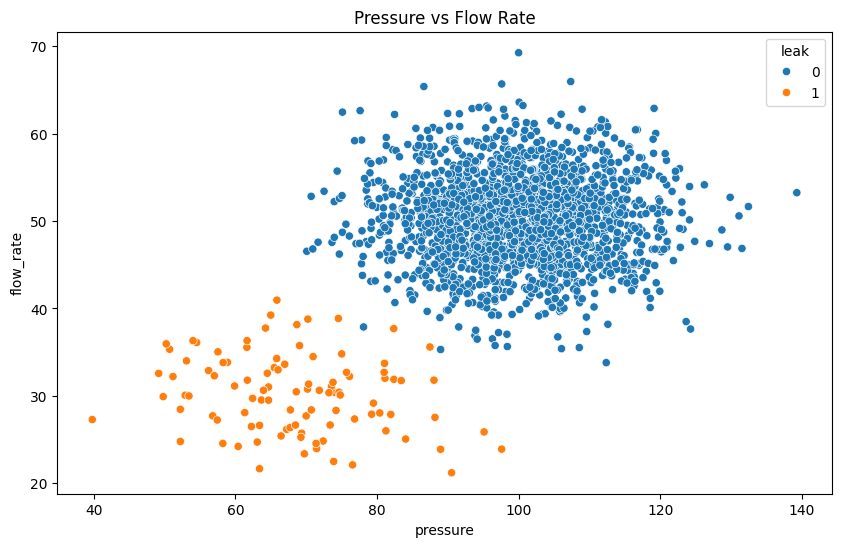

In [7]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=data["pressure"], y=data["flow_rate"], hue=data["leak"])
plt.title("Pressure vs Flow Rate")
plt.show()

In [8]:
X = data.drop("leak", axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
model = IsolationForest(contamination=0.05)

model.fit(X_scaled)

predictions = model.predict(X_scaled)

In [10]:
data["prediction"] = predictions
data["prediction"] = data["prediction"].map({1:0, -1:1})

In [11]:
print(classification_report(data["leak"], data["prediction"]))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1901
           1       0.76      0.77      0.76        99

    accuracy                           0.98      2000
   macro avg       0.87      0.88      0.88      2000
weighted avg       0.98      0.98      0.98      2000



In [12]:
def detect_leak(flow, pressure, temperature, vibration):
    sample = np.array([[flow, pressure, temperature, vibration]])
    sample_scaled = scaler.transform(sample)
    result = model.predict(sample_scaled)
    if result == -1:
        return "Leak Detected"
    else:
        return "Normal Flow"

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

In [14]:
np.random.seed(42)
samples = 3000
flow = np.random.normal(50, 5, samples)
pressure = np.random.normal(100, 10, samples)
temperature = np.random.normal(30, 3, samples)
vibration = np.random.normal(5, 1, samples)
data = pd.DataFrame({
    "flow": flow,
    "pressure": pressure,
    "temperature": temperature,
    "vibration": vibration
})

In [15]:
data["leak"] = 0
leak_indices = np.random.choice(samples, 200)
data.loc[leak_indices, "flow"] -= 20
data.loc[leak_indices, "pressure"] -= 35
data.loc[leak_indices, "vibration"] += 4
data.loc[leak_indices, "leak"] = 1

In [16]:
X = data.drop("leak", axis=1)
y = data["leak"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
X_cnn = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_cnn, y, test_size=0.2, random_state=42
)

In [19]:
model = Sequential()
model.add(Conv1D(filters=32, kernel_size=2, activation='relu', input_shape=(4,1)))
model.add(MaxPooling1D(pool_size=1))
model.add(Conv1D(filters=64, kernel_size=2, activation='relu'))
model.add(MaxPooling1D(pool_size=1))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

C:\Users\xnish\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 3, 32)               │              96 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 3, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 2, 64)               │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 2, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,577 (49.13 KB)

 Trainable params: 12,577 (49.13 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9542 - loss: 0.2231 - val_accuracy: 0.9950 - val_loss: 0.0314
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9967 - loss: 0.0171 - val_accuracy: 0.9983 - val_loss: 0.0079
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9975 - loss: 0.0075 - val_accuracy: 0.9983 - val_loss: 0.0060
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9992 - loss: 0.0037 - val_accuracy: 0.9983 - val_loss: 0.0054
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9987 - loss: 0.0033 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 1.0000 - val_loss: 5.1928e-04
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 3.2047e-04
Epoch 8/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 7.3973e-04 - val_accuracy: 1

In [21]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 1.4103e-04
Test Accuracy: 1.0


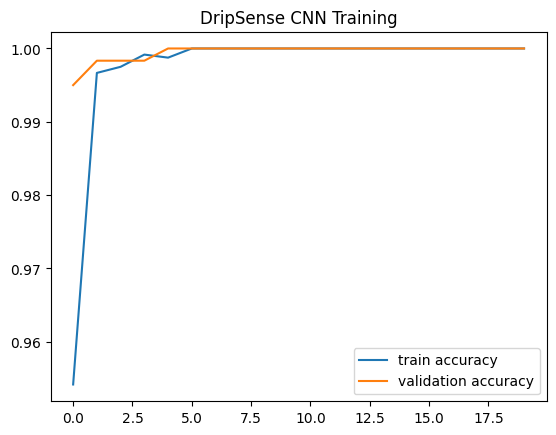

In [22]:
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.legend()
plt.title("DripSense CNN Training")
plt.show()

In [23]:
def detect_leak(flow, pressure, temperature, vibration):
    sample = np.array([[flow, pressure, temperature, vibration]])
    sample_scaled = scaler.transform(sample)
    sample_scaled = sample_scaled.reshape(1,4,1)
    prediction = model.predict(sample_scaled)
    if prediction > 0.5:
        return "Leak Detected"
    else:
        return "Normal Pipeline"

In [24]:
detect_leak(30,60,32,8)

C:\Users\xnish\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step


'Leak Detected'

In [25]:
import time
import random

In [26]:
def generate_sensor_data():
    flow = np.random.normal(50, 5)
    pressure = np.random.normal(100, 10)
    temperature = np.random.normal(30, 3)
    vibration = np.random.normal(5, 1)
    # randomly simulate leak
    if random.random() < 0.1:
        flow -= 20
        pressure -= 35
        vibration += 4
        leak = 1
    else:
        leak = 0
    return flow, pressure, temperature, vibration, leak

In [27]:
def predict_leak(flow, pressure, temperature, vibration):
    sample = np.array([[flow, pressure, temperature, vibration]])
    sample_scaled = scaler.transform(sample)
    sample_scaled = sample_scaled.reshape(1,4,1)
    prediction = model.predict(sample_scaled, verbose=0)
    if prediction > 0.5:
        return "LEAK DETECTED"
    else:
        return "Normal"

In [28]:
print("DripSense Live Monitoring\n")
for i in range(20):
    flow, pressure, temp, vib, actual = generate_sensor_data()
    result = predict_leak(flow, pressure, temp, vib)
    print(f"Reading {i+1}")
    print("Flow:", round(flow,2))
    print("Pressure:", round(pressure,2))
    print("Temperature:", round(temp,2))
    print("Vibration:", round(vib,2))
    print("Prediction:", result)
    time.sleep(1)

DripSense Live Monitoring



C:\Users\xnish\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Reading 1
Flow: 52.46
Pressure: 107.63
Temperature: 28.63
Vibration: 5.5
Prediction: Normal


C:\Users\xnish\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Reading 2
Flow: 48.36
Pressure: 107.19
Temperature: 30.51
Vibration: 5.48
Prediction: Normal


...

Reading 18
Flow: 22.4
Pressure: 68.84
Temperature: 30.0
Vibration: 9.3
Prediction: LEAK DETECTED


C:\Users\xnish\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Reading 19
Flow: 49.48
Pressure: 86.06
Temperature: 31.54
Vibration: 6.92
Prediction: Normal


C:\Users\xnish\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Reading 20
Flow: 52.05
Pressure: 95.74
Temperature: 25.72
Vibration: 4.09
Prediction: Normal


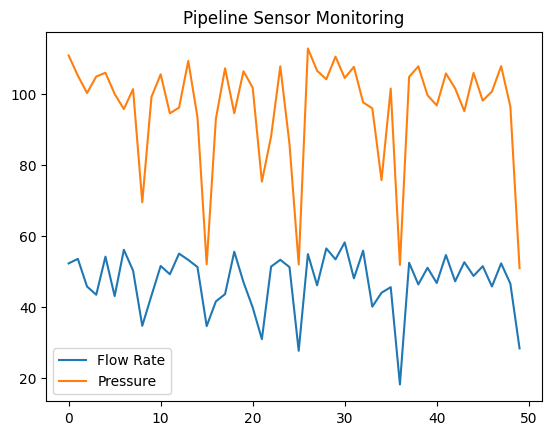

In [29]:
flows = []
pressures = []
for i in range(50):
    flow, pressure, temp, vib, actual = generate_sensor_data()
    flows.append(flow)
    pressures.append(pressure)
plt.plot(flows, label="Flow Rate")
plt.plot(pressures, label="Pressure")
plt.title("Pipeline Sensor Monitoring")
plt.legend()
plt.show()

In [30]:
from matplotlib.animation import FuncAnimation

In [31]:
flow_data = []
pressure_data = []
temp_data = []
vibration_data = []
time_steps = []

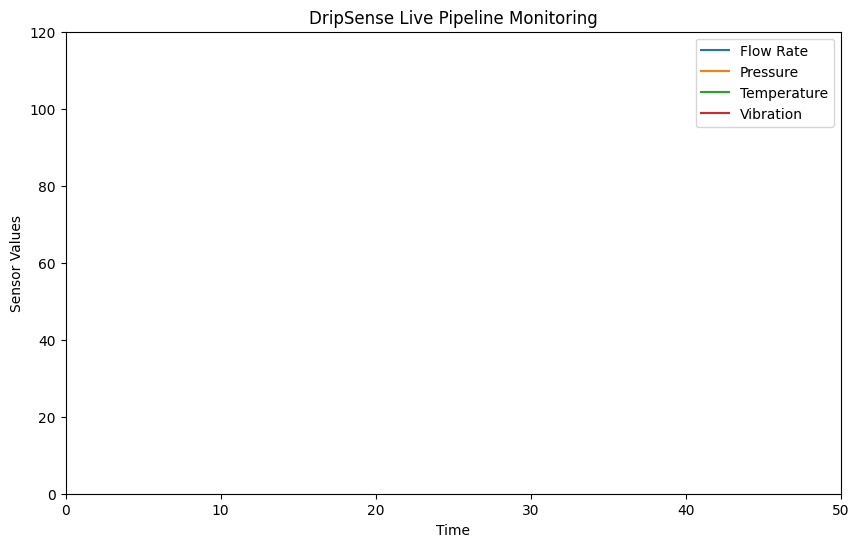

In [32]:
fig, ax = plt.subplots(figsize=(10,6))
line1, = ax.plot([], [], label="Flow Rate")
line2, = ax.plot([], [], label="Pressure")
line3, = ax.plot([], [], label="Temperature")
line4, = ax.plot([], [], label="Vibration")
ax.set_xlim(0,50)
ax.set_ylim(0,120)
ax.set_title("DripSense Live Pipeline Monitoring")
ax.set_xlabel("Time")
ax.set_ylabel("Sensor Values")
ax.legend()

In [33]:
def update(frame):
    flow, pressure, temp, vib, actual = generate_sensor_data()
    prediction = predict_leak(flow, pressure, temp, vib)
    flow_data.append(flow)
    pressure_data.append(pressure)
    temp_data.append(temp)
    vibration_data.append(vib)
    time_steps.append(frame)
    line1.set_data(time_steps, flow_data)
    line2.set_data(time_steps, pressure_data)
    line3.set_data(time_steps, temp_data)
    line4.set_data(time_steps, vibration_data)
    if prediction == "LEAK DETECTED":
        print("ALERT: Pipeline Leak Detected")
    return line1, line2, line3, line4

In [35]:
animation = FuncAnimation(
    fig,
    update,
    frames=50,
    interval=1000
)
plt.show()

C:\Users\xnish\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


In [36]:
from mpl_toolkits.mplot3d import Axes3D

In [37]:
pipe_x = np.linspace(0, 10, 50)
pipe_y = np.zeros(50)
pipe_z = np.zeros(50)

Text(0.5, 0.92, 'DripSense Pipeline Monitoring')

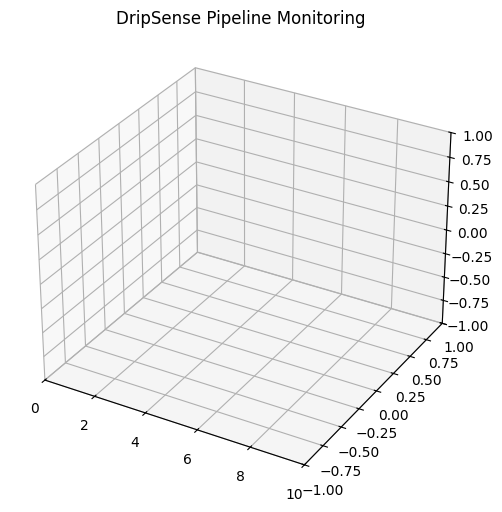

In [38]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlim(0,10)
ax.set_ylim(-1,1)
ax.set_zlim(-1,1)
ax.set_title("DripSense Pipeline Monitoring")

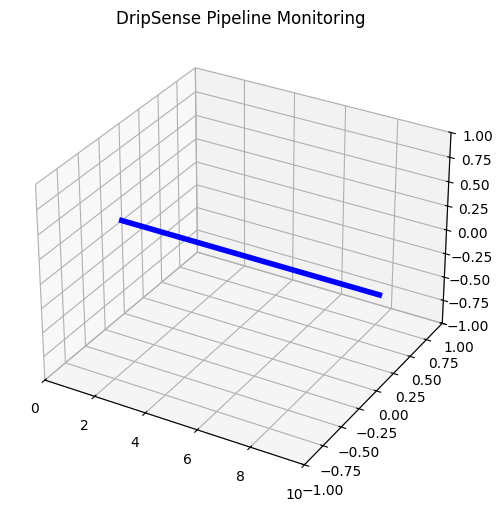

In [39]:
pipe_x = np.linspace(0, 10, 50)
pipe_y = np.zeros(50)
pipe_z = np.zeros(50)
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')
# draw pipeline immediately
ax.plot(pipe_x, pipe_y, pipe_z, color='blue', linewidth=4)
ax.set_xlim(0,10)
ax.set_ylim(-1,1)
ax.set_zlim(-1,1)
ax.set_title("DripSense Pipeline Monitoring")
plt.show()

In [40]:
def simulate_pipeline():
    for i in range(20):
        flow, pressure, temp, vib, actual = generate_sensor_data()
        prediction = predict_leak(flow, pressure, temp, vib)
        ax.clear()
        ax.plot(pipe_x, pipe_y, pipe_z, color='blue', linewidth=4)
        if prediction == "LEAK DETECTED":
            leak_position = random.randint(0,49)
            ax.scatter(
                pipe_x[leak_position],
                pipe_y[leak_position],
                pipe_z[leak_position],
                color='red',
                s=200
            )
            print("Leak detected at segment", leak_position)
        ax.set_xlim(0,10)
        ax.set_ylim(-1,1)
        ax.set_zlim(-1,1)
        plt.pause(1)
    plt.show()

In [41]:
simulate_pipeline()

C:\Users\xnish\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Leak detected at segment 27


C:\Users\xnish\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Leak detected at segment 22


C:\Users\xnish\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\xnish\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\xnish\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\xnish\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\xnish\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: U

In [42]:
def predict_leak(flow, pressure, temperature, vibration):
    sample = pd.DataFrame({
        "flow":[flow],
        "pressure":[pressure],
        "temperature":[temperature],
        "vibration":[vibration]
    })
    sample_scaled = scaler.transform(sample)
    sample_scaled = sample_scaled.reshape(1,4,1)
    prediction = model.predict(sample_scaled, verbose=0)
    if prediction > 0.5:
        return "LEAK DETECTED"
    else:
        return "Normal"

In [43]:
import warnings
warnings.filterwarnings("ignore")

In [44]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import time

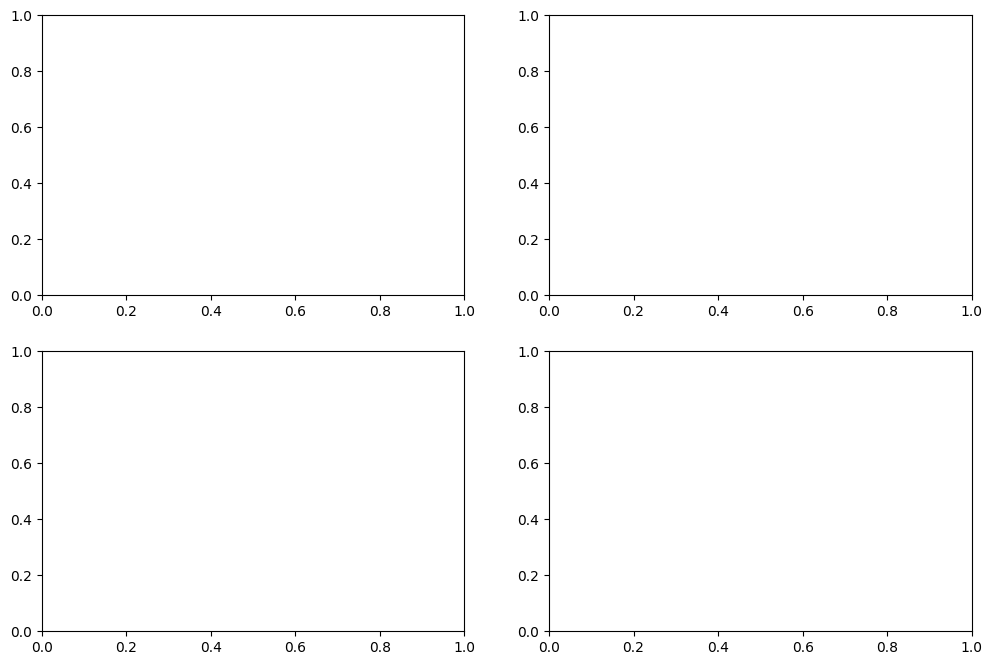

In [48]:
fig, axs = plt.subplots(2,2, figsize=(12,8))
flow_plot = []
pressure_plot = []
temp_plot = []
vib_plot = []
time_plot = []

In [46]:
def update_dashboard(frame):
    flow, pressure, temp, vib, actual = generate_sensor_data()
    prediction = predict_leak(flow, pressure, temp, vib)
    flow_plot.append(flow)
    pressure_plot.append(pressure)
    temp_plot.append(temp)
    vib_plot.append(vib)
    time_plot.append(frame)
    for ax in axs.flat:
        ax.clear()
    axs[0,0].plot(time_plot, flow_plot)
    axs[0,0].set_title("Flow Rate")
    axs[0,1].plot(time_plot, pressure_plot)
    axs[0,1].set_title("Pressure")
    axs[1,0].plot(time_plot, temp_plot)
    axs[1,0].set_title("Temperature")
    axs[1,1].plot(time_plot, vib_plot)
    axs[1,1].set_title("Vibration")
    if prediction == "LEAK DETECTED":
        print("CRITICAL ALERT: Pipeline Leak Detected")

In [47]:
animation = FuncAnimation(
    fig,
    update_dashboard,
    frames=50,
    interval=1000
)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>